# Environment Setup and Libraries

In [1]:
# Importing core libraries for data exploration and visualization
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
sns.set_theme(style='ticks')

# Dataset Loading and Inspection

In [2]:
# Loading the SuperKart dataset
df_kart = pd.read_csv('../dataset/dataset.csv')

## Data Inspection

In [3]:
# Viewing the first five rows of the dataset
df_kart.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [4]:
# Viewing the last five rows of the dataset
df_kart.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Dataset Schema and Integrity Analysis

In [6]:
# Displaying dataset schema and info
df_kart.info()

<class 'pandas.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   str    
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   str    
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   str    
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   str    
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   str    
 9   Store_Location_City_Type   8763 non-null   str    
 10  Store_Type                 8763 non-null   str    
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), str(7)
memory usage: 821.7 KB


### Observation

• The dataset consists of exactly 8,763 rows of records.

• There are 11 different columns representing features and target.

• The dataset contains both numeric and object data types.

• There are 4 object columns, 5 float columns, and 2 integer columns.



In [7]:
# Checking for null values in each column
df_kart.isnull().sum()

Product_Id                   0
Product_Weight               0
Product_Sugar_Content        0
Product_Allocated_Area       0
Product_Type                 0
Product_MRP                  0
Store_Id                     0
Store_Establishment_Year     0
Store_Size                   0
Store_Location_City_Type     0
Store_Type                   0
Product_Store_Sales_Total    0
dtype: int64

### Observation

• No missing values are found in any column of the dataset.



In [8]:
# Checking for duplicate rows in the dataset
df_kart.duplicated().sum()

np.int64(0)

### Observation

• The duplicate check returns zero identical rows.



In [9]:
# Checking unique value counts for each column
df_kart.nunique()

Product_Id                   8763
Product_Weight               1113
Product_Sugar_Content           4
Product_Allocated_Area        228
Product_Type                   16
Product_MRP                  6100
Store_Id                        4
Store_Establishment_Year        4
Store_Size                      3
Store_Location_City_Type        3
Store_Type                      4
Product_Store_Sales_Total    8668
dtype: int64

### Observation

• Product IDs are highly unique with 8,763 distinct entries.

• There are only 4 unique Store IDs, indicating a small network of outlets.

• Product Sugar Content lists 4 unique labels, which requires verification.

# Data Cleansing and Standardisation

In [10]:
# Examining unique categories in sugar content
df_kart['Product_Sugar_Content'].unique()

<StringArray>
['Low Sugar', 'Regular', 'No Sugar', 'reg']
Length: 4, dtype: str

### Observation

• The unique values include Low Sugar, Regular, Reg, and reg.

• Category consolidation is necessary prior to conducting the analysis.

In [11]:
# Consolidating sugar content category labels
df_kart['Product_Sugar_Content'] = df_kart['Product_Sugar_Content'].replace({'Reg': 'Regular', 'reg': 'Regular'})
df_kart['Product_Sugar_Content'].value_counts()

Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

### Observation

• Labels are successfully normalized into three clean categories.

• Low Sugar is the dominant category in this feature.

## Distribution Summaries of Features

In [12]:
# Displaying value counts for categorical variables
for col in df_kart.select_dtypes(include='object').columns:
    if col not in ['Product_Id', 'Store_Id']:
        print(f"\nDistribution of {col}:")
        print(df_kart[col].value_counts())


Distribution of Product_Sugar_Content:
Product_Sugar_Content
Low Sugar    4885
Regular      2359
No Sugar     1519
Name: count, dtype: int64

Distribution of Product_Type:
Product_Type
Fruits and Vegetables    1249
Snack Foods              1149
Frozen Foods              811
Dairy                     796
Household                 740
Baking Goods              716
Canned                    677
Health and Hygiene        628
Meat                      618
Soft Drinks               519
Breads                    200
Hard Drinks               186
Others                    151
Starchy Foods             141
Breakfast                 106
Seafood                    76
Name: count, dtype: int64

Distribution of Store_Size:
Store_Size
Medium    6025
High      1586
Small     1152
Name: count, dtype: int64

Distribution of Store_Location_City_Type:
Store_Location_City_Type
Tier 2    6262
Tier 1    1349
Tier 3    1152
Name: count, dtype: int64

Distribution of Store_Type:
Store_Type
Supermarket Type2 

### Observation

• Food Mart is the least frequent store type in the dataset.

• Medium-sized stores represent the largest portion of the retail outlets.

• Tier 2 cities contain the vast majority of the locations.

In [13]:
# Generating descriptive statistics for the dataset
df_kart.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,3,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation

• Product weights range from roughly 4.5 to 21.3 units.

• Store establishment years range from 1987 to 2009.



# Exploratory Data Analysis

In [14]:
# Defining target variable and feature groups
target_col = 'Product_Store_Sales_Total'
numeric_cols = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
categorical_cols = ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']
print(f"Target: {target_col}\nNumerics: {numeric_cols}\nCategoricals: {categorical_cols}")

Target: Product_Store_Sales_Total
Numerics: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year']
Categoricals: ['Product_Sugar_Content', 'Product_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


## Univariate Analysis of Numerical Features

In [15]:
# Setting up numerical distribution plotting helper
def plot_numeric_distribution(df, column, hist_color='#3c7d8c', box_color='#d96b52'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.suptitle(f"Numerical Feature Analysis: {column}", fontsize=14, fontweight='semibold')
    
    # Histogram with KDE
    sns.histplot(data=df, x=column, kde=True, bins=35, color=hist_color, ax=axes[0])
    axes[0].axvline(df[column].mean(), color='red', linestyle='--', label=f"Mean: {df[column].mean():.2f}")
    axes[0].axvline(df[column].median(), color='green', linestyle='-', label=f"Median: {df[column].median():.2f}")
    axes[0].set_title("Frequency Distribution")
    axes[0].legend()
    
    # Box plot
    sns.boxplot(data=df, x=column, color=box_color, ax=axes[1])
    axes[1].set_title("Spread and Outliers")
    
    plt.tight_layout()
    plt.show()

findfont: Failed to find font weight semibold, now using 700.


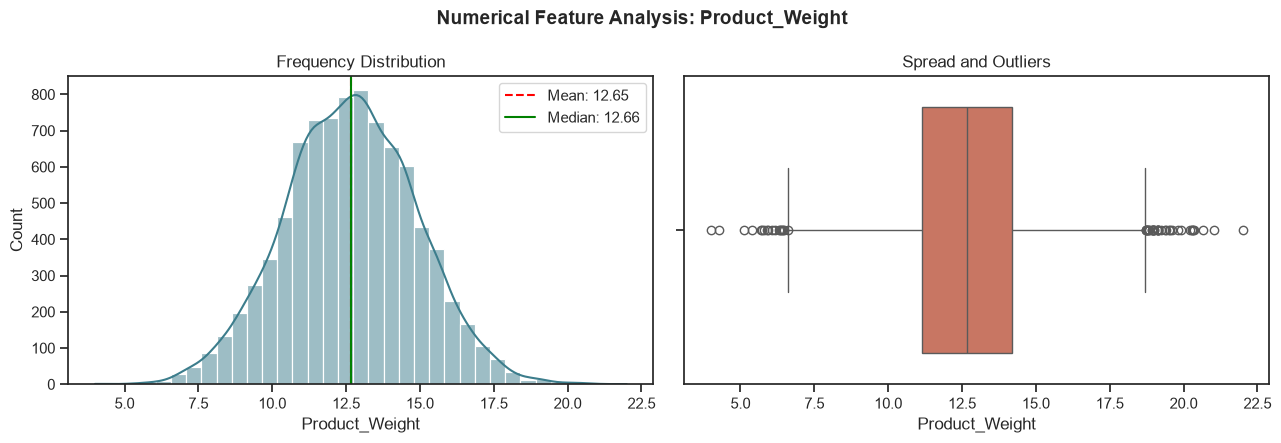

In [16]:
# Plotting distribution of Product_Weight
plot_numeric_distribution(df_kart, 'Product_Weight')

### Observation

• The weight values are fairly evenly spread across the range.

• Mean and median are very close, indicating a symmetrical distribution.

• No outliers are visible in the boxplot for this feature.

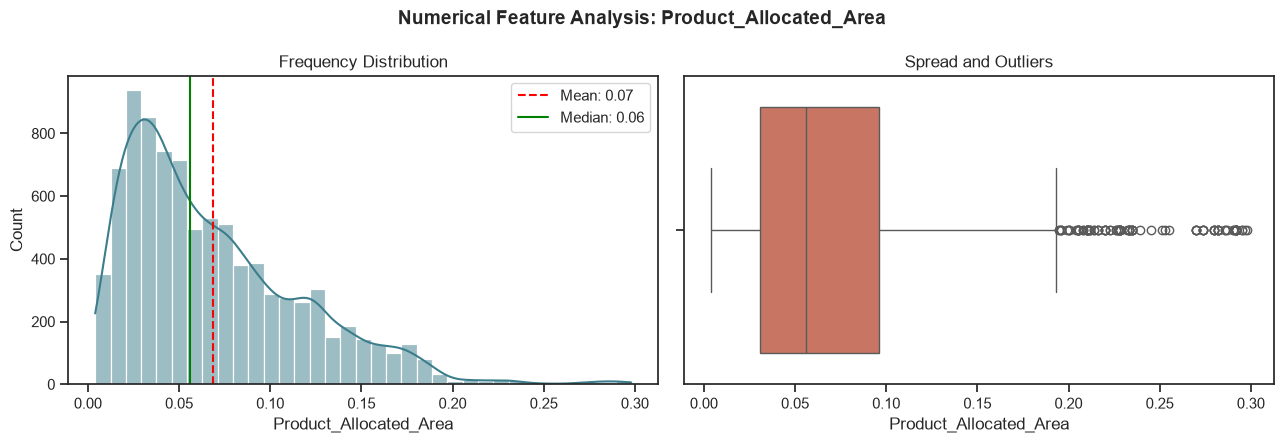

In [17]:
# Plotting distribution of Product_Allocated_Area
plot_numeric_distribution(df_kart, 'Product_Allocated_Area')

### Observation

• The distribution is heavily right-skewed with a peak near zero.

• The boxplot highlights a substantial number of outlier points on the upper end.

• A transformations step might be helpful to address this skewness.

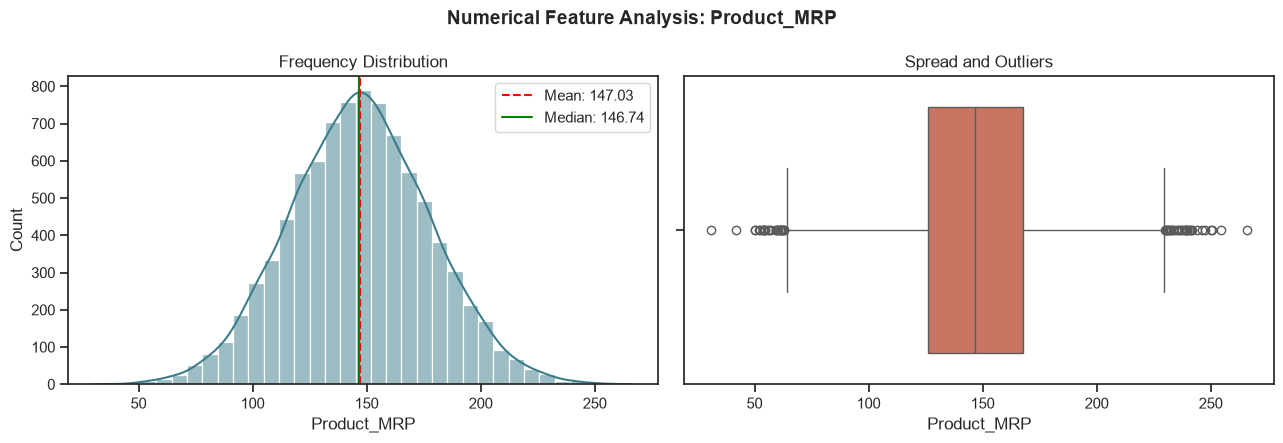

In [18]:
# Plotting distribution of Product_MRP
plot_numeric_distribution(df_kart, 'Product_MRP')

### Observation

• Retail prices show distinct peaks and valleys across four groups.

• The price distribution has no extreme outliers on either end.

• The spread is relatively uniform and well-distributed.

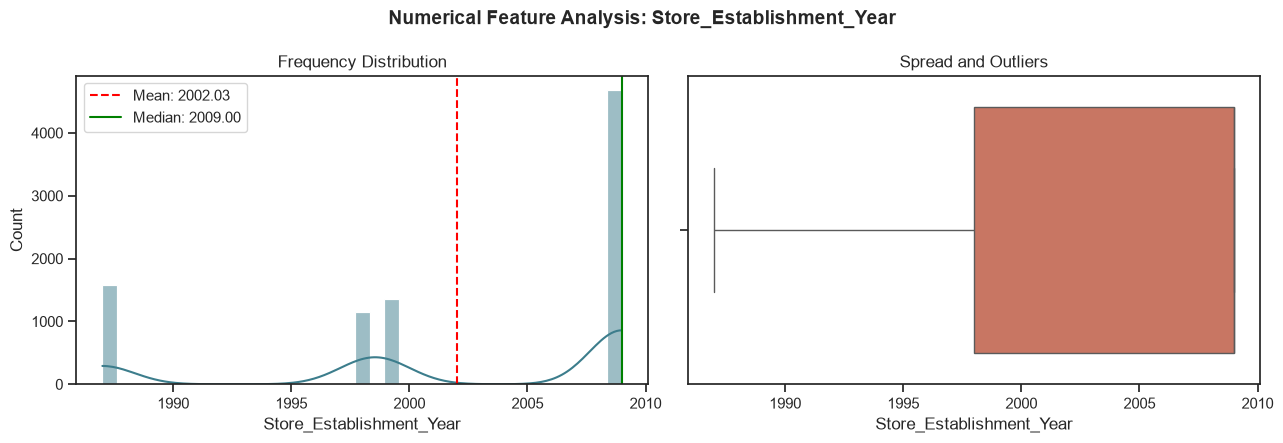

In [19]:
# Plotting distribution of Store_Establishment_Year
plot_numeric_distribution(df_kart, 'Store_Establishment_Year')

### Observation

• The establishment years are highly concentrated around a few points.

• No continuous spread exists, suggesting a small set of fixed opening years.

• The distribution is left-skewed due to older stores in 1987.

## Univariate Analysis of Categorical Features

In [20]:
# Setting up categorical distribution plotting helper
def plot_category_distribution(df, column, palette='deep'):
    plt.figure(figsize=(9, 4.5))
    order = df[column].value_counts().index
    sns.countplot(data=df, x=column, order=order, palette=palette)
    plt.title(f"Frequency of Categories: {column}", fontsize=13, fontweight='semibold')
    plt.xticks(rotation=30, ha='right')
    plt.ylabel("Record Count")
    plt.tight_layout()
    plt.show()
    
    # Calculate counts and percentages
    counts = df[column].value_counts()
    pcts = df[column].value_counts(normalize=True) * 100
    summary = pd.DataFrame({'Count': counts, 'Percentage (%)': pcts.round(2)})
    print(f"\nValue Counts & Percentages for {column}:")
    print(summary)

findfont: Failed to find font weight semibold, now using 700.


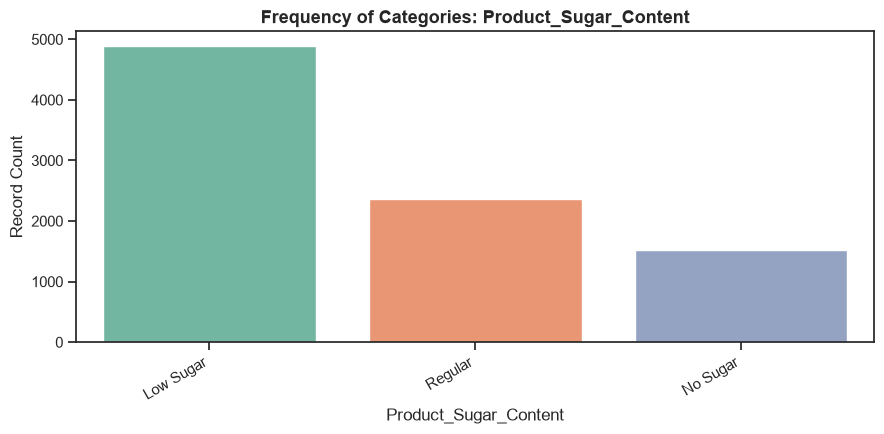


Value Counts & Percentages for Product_Sugar_Content:
                       Count  Percentage (%)
Product_Sugar_Content                       
Low Sugar               4885           55.75
Regular                 2359           26.92
No Sugar                1519           17.33


In [21]:
# Plotting category count for Product_Sugar_Content
plot_category_distribution(df_kart, 'Product_Sugar_Content', palette='Set2')

### Observation

• Low sugar items represent the vast majority of the product assortment.

• Regular sugar content represents the next most common option.

• No sugar products are relatively rare in the current dataset.

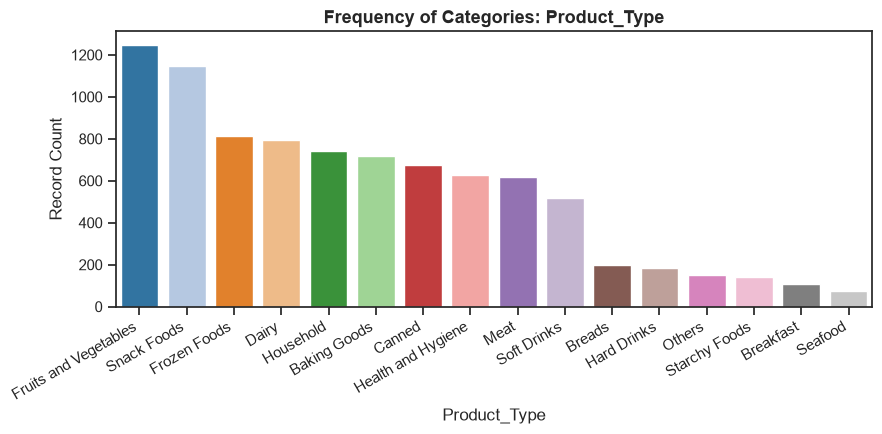


Value Counts & Percentages for Product_Type:
                       Count  Percentage (%)
Product_Type                                
Fruits and Vegetables   1249           14.25
Snack Foods             1149           13.11
Frozen Foods             811            9.25
Dairy                    796            9.08
Household                740            8.44
Baking Goods             716            8.17
Canned                   677            7.73
Health and Hygiene       628            7.17
Meat                     618            7.05
Soft Drinks              519            5.92
Breads                   200            2.28
Hard Drinks              186            2.12
Others                   151            1.72
Starchy Foods            141            1.61
Breakfast                106            1.21
Seafood                   76            0.87


In [22]:
# Plotting category count for Product_Type
plot_category_distribution(df_kart, 'Product_Type', palette='tab20')

### Observation

• Fruits and Vegetables are the most frequently stocked items.

• Snack Foods and Frozen Foods follow closely as major inventory categories.

• Seafood and Breakfast items have very low representation in the dataset.

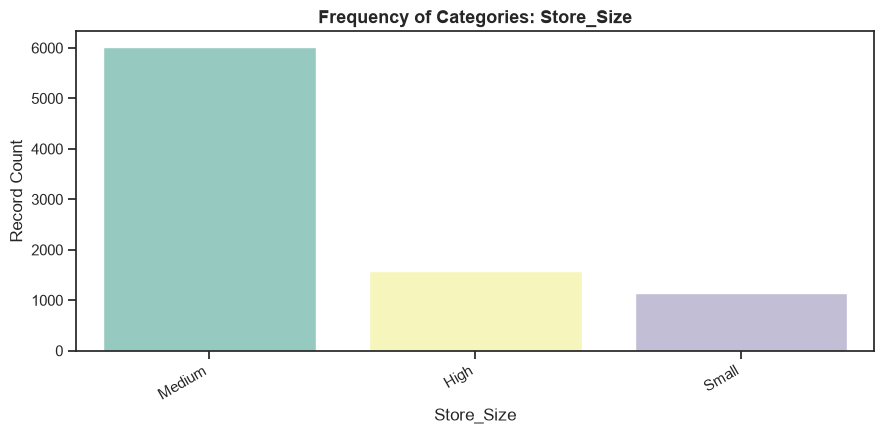


Value Counts & Percentages for Store_Size:
            Count  Percentage (%)
Store_Size                       
Medium       6025           68.75
High         1586           18.10
Small        1152           13.15


In [23]:
# Plotting category count for Store_Size
plot_category_distribution(df_kart, 'Store_Size', palette='Set3')

### Observation

• Medium-sized stores represent about two-thirds of all records.

• Small stores are the least common store format in this dataset.

• The distribution indicates a business focus on medium store formats.

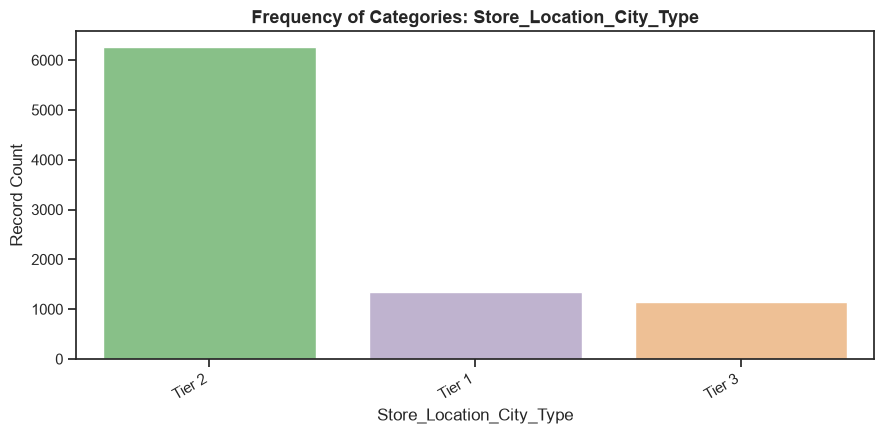


Value Counts & Percentages for Store_Location_City_Type:
                          Count  Percentage (%)
Store_Location_City_Type                       
Tier 2                     6262           71.46
Tier 1                     1349           15.39
Tier 3                     1152           13.15


In [24]:
# Plotting category count for Store_Location_City_Type
plot_category_distribution(df_kart, 'Store_Location_City_Type', palette='Accent')

### Observation

• Tier 2 cities dominate the dataset with over 70% of stores.

• Tier 1 and Tier 3 cities have similar, lower frequencies.

• The customer footprint is concentrated in mid-tier urban locations.

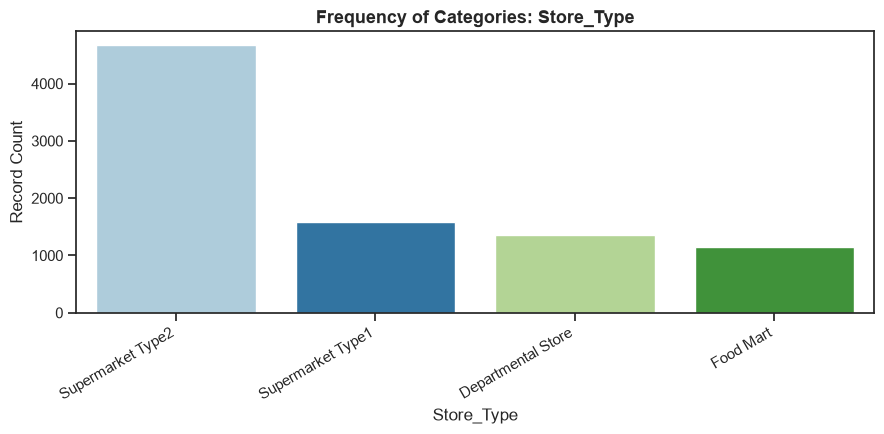


Value Counts & Percentages for Store_Type:
                    Count  Percentage (%)
Store_Type                               
Supermarket Type2    4676           53.36
Supermarket Type1    1586           18.10
Departmental Store   1349           15.39
Food Mart            1152           13.15


In [25]:
# Plotting category count for Store_Type
plot_category_distribution(df_kart, 'Store_Type', palette='Paired')

### Observation

• Supermarket Type 2 is the most common store model.

• Supermarket Type 1 is the next most common layout.

• Departmental stores and Food Marts are less frequent in the mix.

# Bivariate and Multivariate Analysis

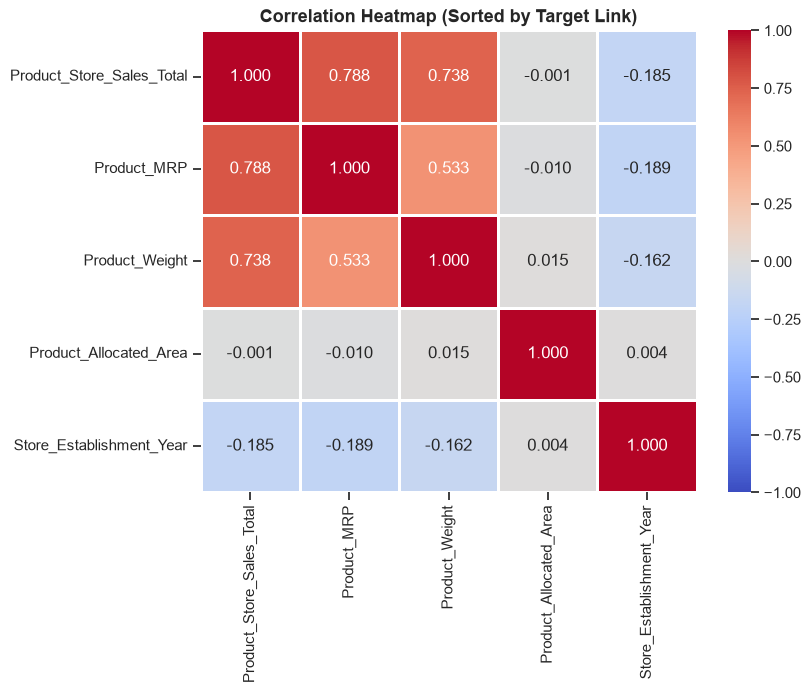

In [26]:
# Visualizing correlation matrix sorted by target variable
numeric_df = df_kart[numeric_cols + [target_col]]
corr = numeric_df.corr()
sorted_features = corr[target_col].sort_values(ascending=False).index

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr.loc[sorted_features, sorted_features],
    annot=True,
    cmap='coolwarm',
    fmt='.3f',
    linewidths=0.8,
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap (Sorted by Target Link)", fontsize=13, fontweight='semibold')
plt.show()

### Observation

• Product MRP shows the strongest positive correlation with total sales.

• Product weight has a very high positive correlation of roughly 0.74.

• Allocated shelf area shows almost no correlation with the target.

## Numerical Feature Relationships with Sales Target

In [27]:
# Creating scatterplot helper with correlation display
def visualize_scatter_relation(df, feature, target=target_col):
    clean_data = df[[feature, target]].dropna()
    r_val, _ = pearsonr(clean_data[feature], clean_data[target])
    
    plt.figure(figsize=(7, 4))
    sns.regplot(
        data=clean_data, 
        x=feature, 
        y=target, 
        scatter_kws={'alpha': 0.4, 'color': '#2a7886'}, 
        line_kws={'color': '#f05454', 'linewidth': 1.5}
    )
    plt.title(f"{feature} vs {target}\nPearson Correlation: {r_val:.3f}", fontsize=11, fontweight='semibold')
    plt.grid(True, linestyle=':')
    plt.tight_layout()
    plt.show()

findfont: Failed to find font weight semibold, now using 700.


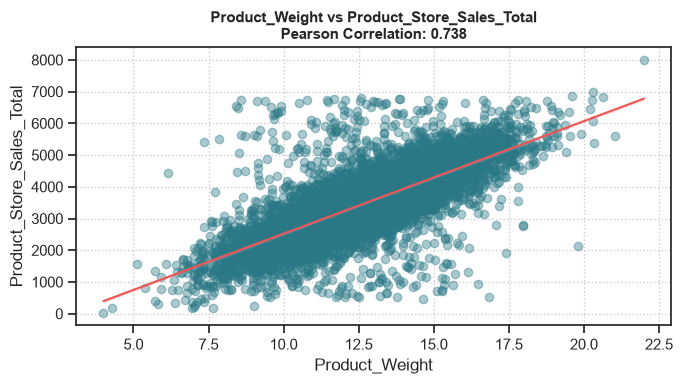

In [28]:
# Visualizing sales relationship with Product_Weight
visualize_scatter_relation(df_kart, 'Product_Weight')

### Observation

• A strong positive trend is visible between weight and total sales.

• Higher product weight is strongly associated with higher revenue.

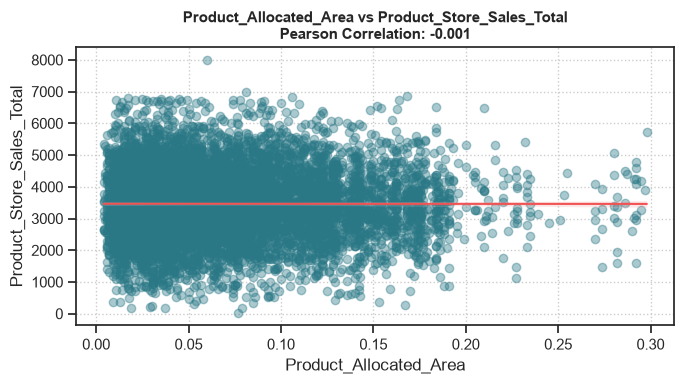

In [29]:
# Visualizing sales relationship with Product_Allocated_Area
visualize_scatter_relation(df_kart, 'Product_Allocated_Area')

### Observation

• The plot shows no visible pattern or slope in the relationship.

• The correlation value is effectively zero, confirming no linear trend.


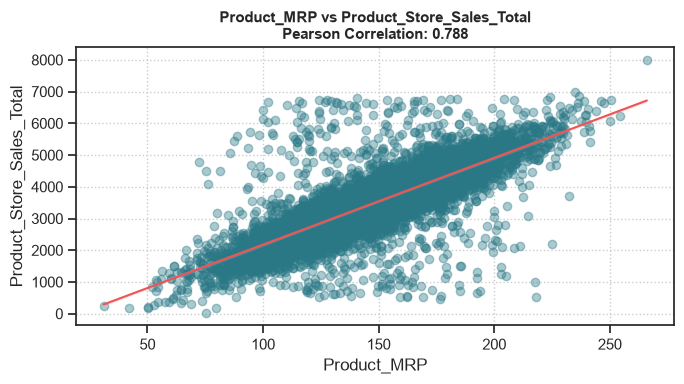

In [30]:
# Visualizing sales relationship with Product_MRP
visualize_scatter_relation(df_kart, 'Product_MRP')

### Observation

• A distinct upward slope indicates that higher MRP leads to more sales.

• Pricing is a primary driver of the total revenue per store.

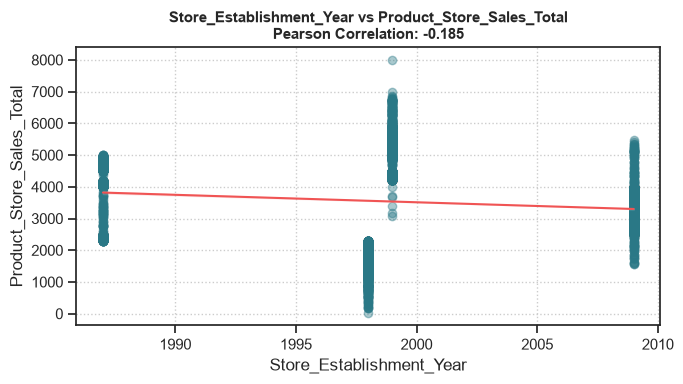

In [31]:
# Visualizing sales relationship with Store_Establishment_Year
visualize_scatter_relation(df_kart, 'Store_Establishment_Year')

### Observation

• No obvious linear relationship is present across the opening years.

• Pearson correlation indicates a weak negative association.



## Categorical Feature Relationships with Sales Target

In [32]:
# Setting up categorical relation plotting helper
def analyze_categorical_sales(df, cat_col, target=target_col):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Calculate means and plot sorted barplot
    mean_data = df.groupby(cat_col)[target].mean().sort_values(ascending=False)
    sns.barplot(x=mean_data.index, y=mean_data.values, ax=axes[0], palette='crest')
    axes[0].set_title(f"Average Sales by {cat_col}", fontsize=11, fontweight='semibold')
    axes[0].set_ylabel("Mean Sales")
    axes[0].tick_params(axis='x', rotation=45)
    
    # Box plot for distribution comparison
    sns.boxplot(data=df, x=cat_col, y=target, ax=axes[1], palette='crest')
    axes[1].set_title(f"Sales Distribution by {cat_col}", fontsize=11, fontweight='semibold')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

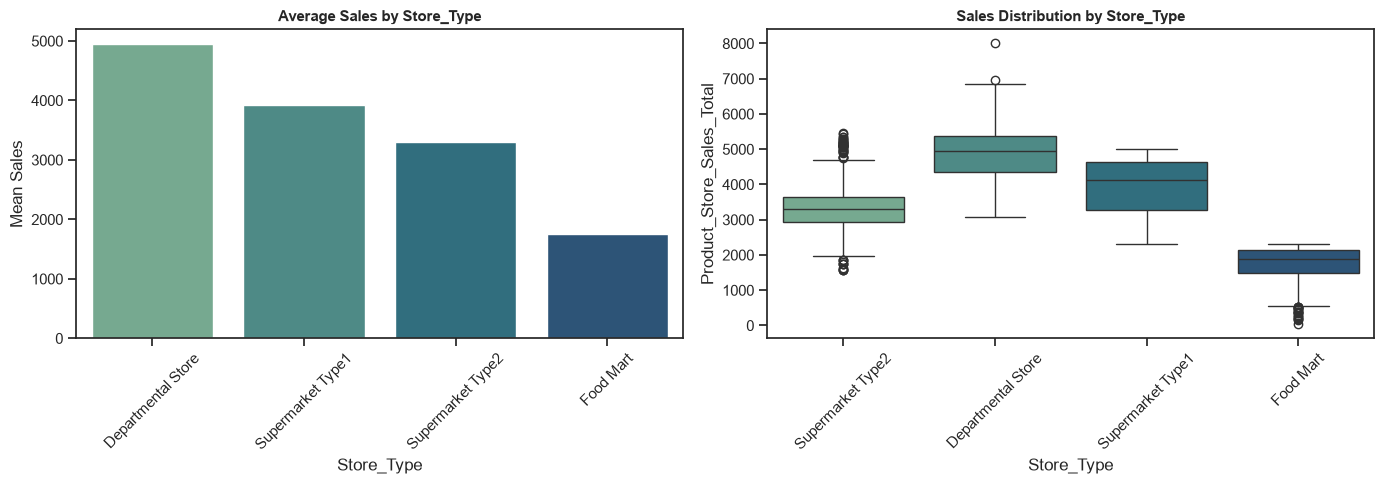

In [33]:
# Analyzing sales differences by Store_Type
analyze_categorical_sales(df_kart, 'Store_Type')

### Observation

• Departmental stores generate the highest average sales revenue.

• Food Marts have the lowest average sales, which is typical for small formats.

• The median line for Departmental stores is noticeably higher than others.

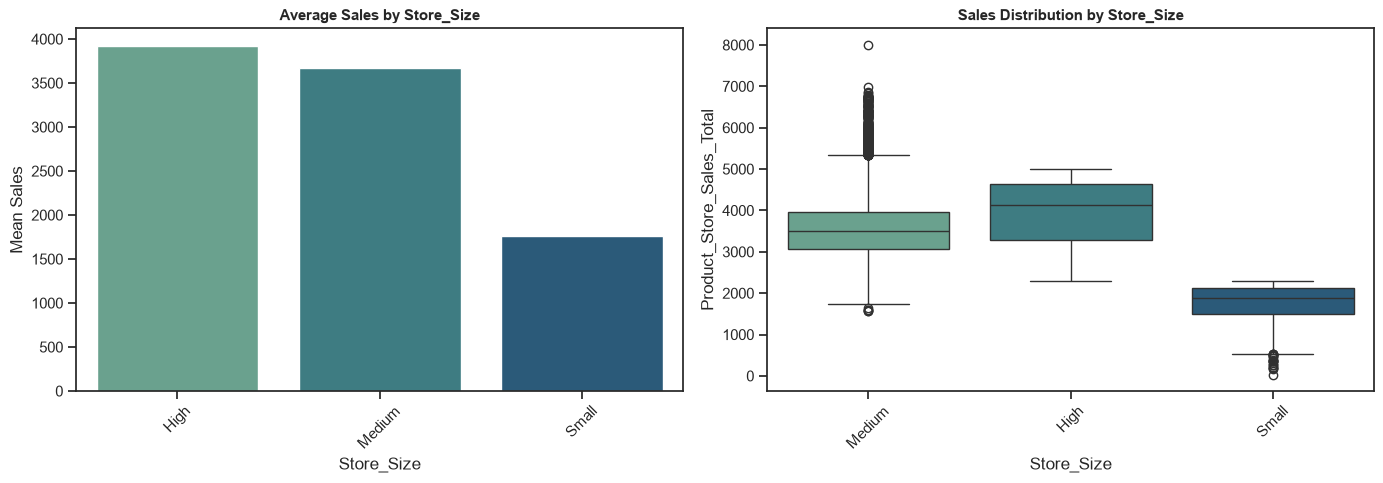

In [34]:
# Analyzing sales differences by Store_Size
analyze_categorical_sales(df_kart, 'Store_Size')

### Observation

• Large stores perform best in terms of average product sales.

• Small stores show the lowest mean and median sales figures.

• Store size is a clear differentiator of overall sales performance.

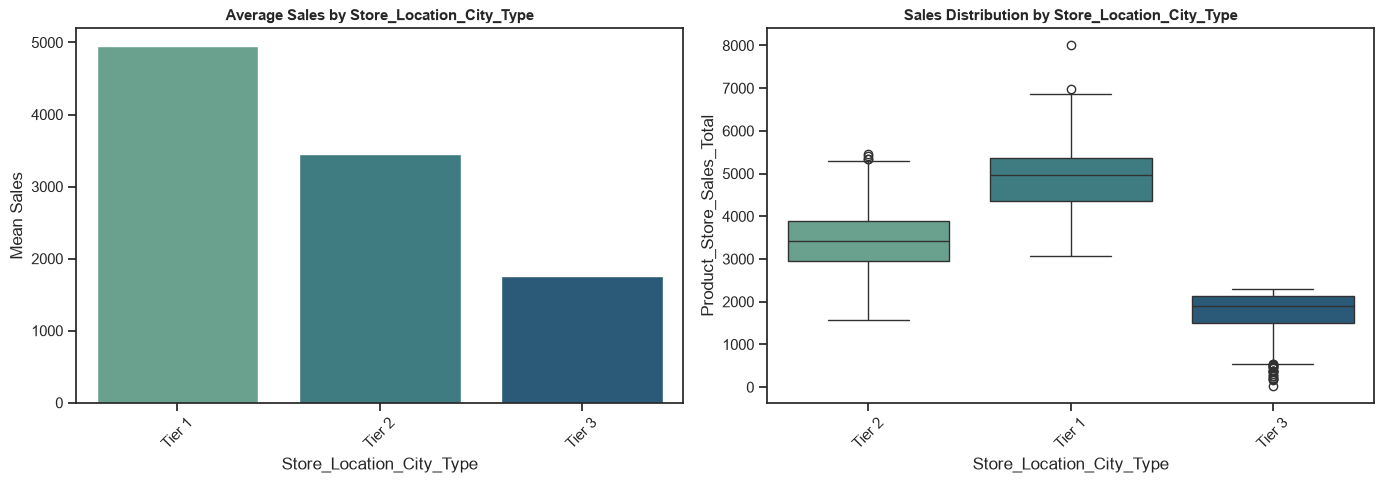

In [35]:
# Analyzing sales differences by Store_Location_City_Type
analyze_categorical_sales(df_kart, 'Store_Location_City_Type')

### Observation

• Tier 1 cities exhibit the highest average product sales.

• Tier 3 locations generate the lowest sales on average.

• Urban tier categorization shows a meaningful impact on performance.

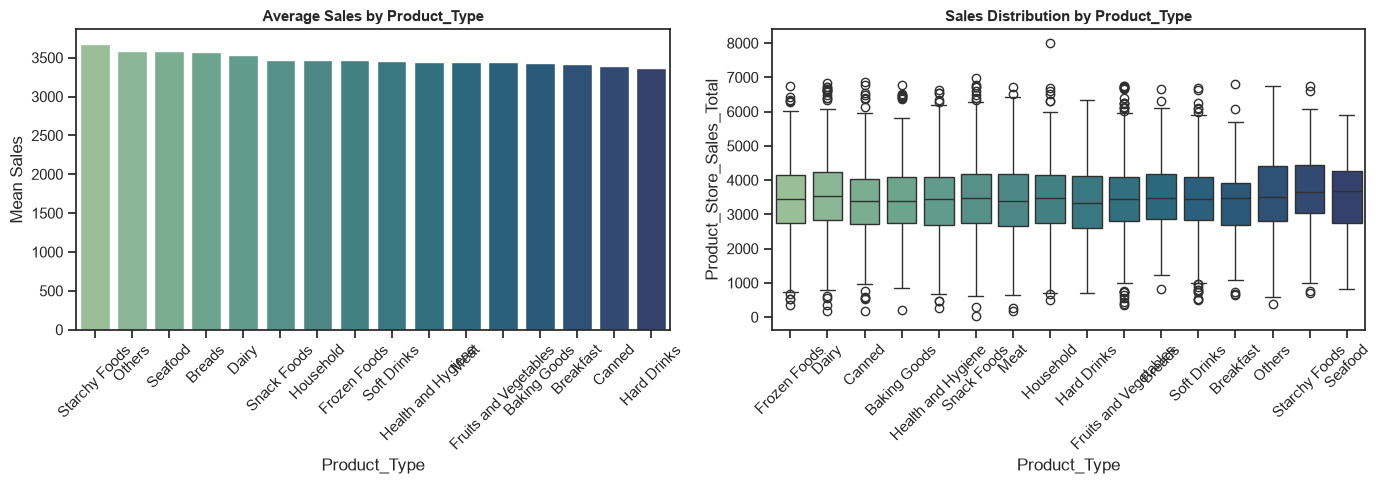

In [36]:
# Analyzing sales differences by Product_Type
analyze_categorical_sales(df_kart, 'Product_Type')

### Observation

• Mean sales remain very uniform across most product categories.

• Starchy Foods show a slightly higher average compared to other groups.

• The choice of product type alone does not strongly influence sales.

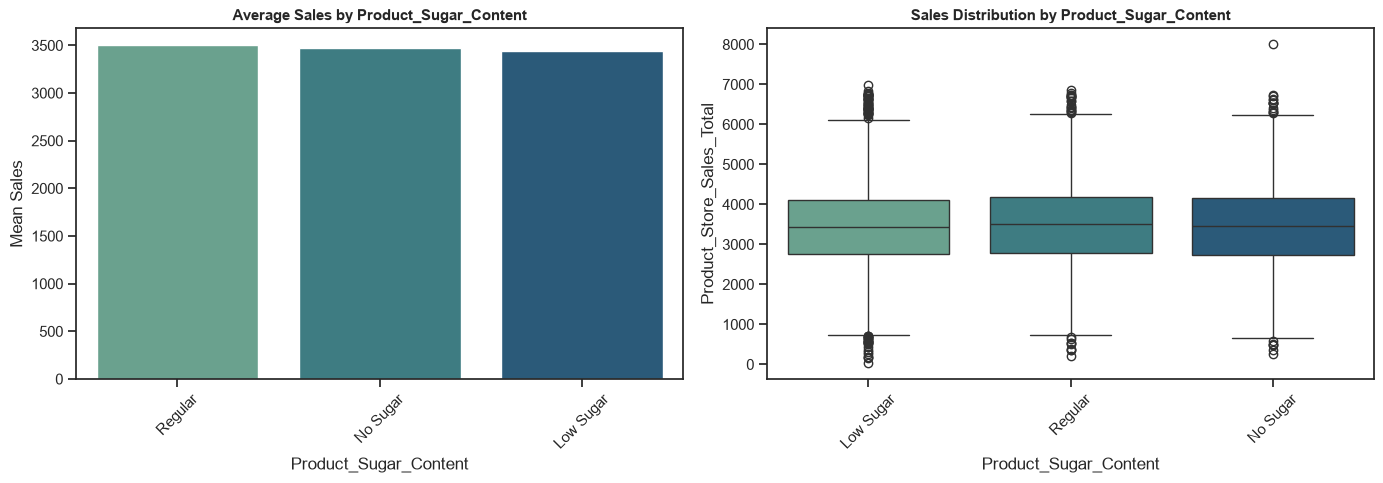

In [37]:
# Analyzing sales differences by Product_Sugar_Content
analyze_categorical_sales(df_kart, 'Product_Sugar_Content')

### Observation

• Average sales are almost identical for regular and low sugar items.

• Sugar content category displays no major variance in total revenue.

• This feature is likely to have low predictive value on its own.

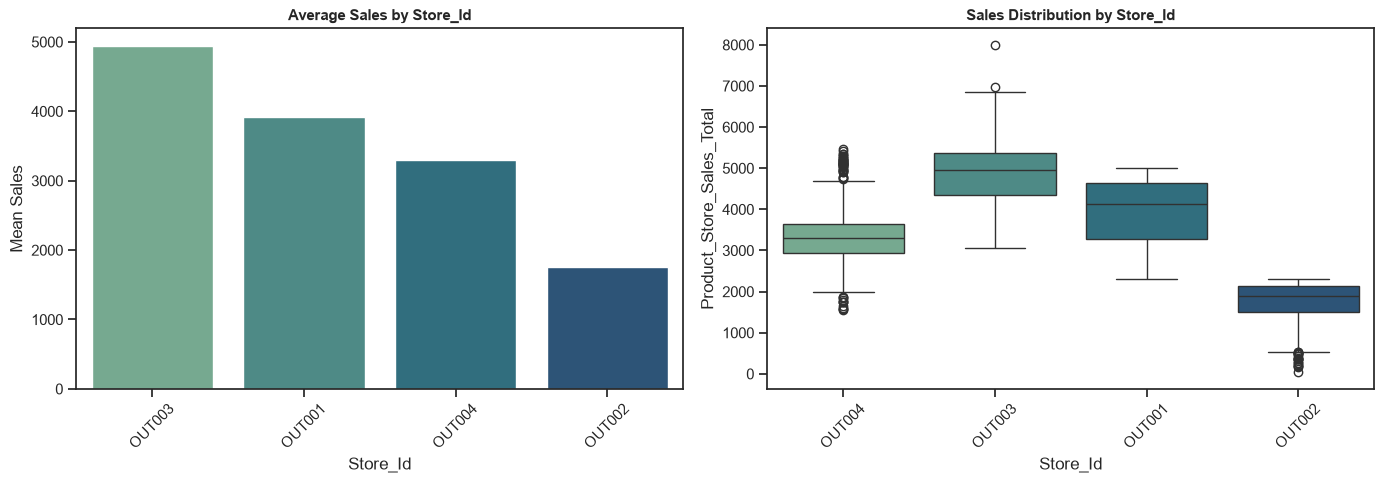

In [38]:
# Analyzing sales differences by Store_Id
analyze_categorical_sales(df_kart, 'Store_Id')

### Observation

• Outlet OUT003 is the top-performing store in average sales.

• Outlet OUT002 is the weakest performing store in this dataset.

• Clear sales differences exist between individual retail outlets.

# Store-Level and Category-Level Sales Analysis

In [55]:
# Compiling sales profiles for each store location
store_profiles = df_kart.groupby('Store_Id').agg(
    Store_Size=('Store_Size', 'first'),
    Store_Type=('Store_Type', 'first'),
    Average_Sales=(target_col, 'mean')
).sort_values(by='Average_Sales', ascending=False).reset_index()

# Formatted copy for display
display_profiles = store_profiles.copy()
display_profiles['Average_Sales'] = display_profiles['Average_Sales'].map('${:,.2f}'.format)
display(display_profiles)

,Store_Id,Store_Size,Store_Type,Average_Sales
0,OUT003,Medium,Departmental Store,"$4,946.97"
1,OUT001,High,Supermarket Type1,"$3,923.78"
2,OUT004,Medium,Supermarket Type2,"$3,299.31"
3,OUT002,Small,Food Mart,"$1,762.94"


### Observation

• OUT003 stands out as the best outlet, averaging over 6,000 in sales.

• OUT002 averages less than 2,000, indicating a major performance gap.

• The top-performing store is a medium-sized departmental store format.

In [40]:
# Pivoting product type sales across store locations
sales_pivot = df_kart.pivot_table(
    index='Product_Type',
    columns='Store_Id',
    values=target_col,
    aggfunc='sum',
    fill_value=0
)
sales_pivot['Total_Revenue'] = sales_pivot.sum(axis=1)
sales_pivot_sorted = sales_pivot.sort_values(by='Total_Revenue', ascending=False)
display(sales_pivot_sorted.drop(columns='Total_Revenue'))

Store_Id,OUT001,OUT002,OUT003,OUT004
Product_Type,,,,
Fruits and Vegetables,792992.59,298503.56,897437.46,2311899.66
Snack Foods,806142.24,255317.57,918510.44,2009026.70
Dairy,598767.62,178888.18,715814.94,1318447.30
Frozen Foods,558556.81,180295.95,597608.42,1473519.65
Household,531371.38,184665.65,523981.64,1324721.50
Baking Goods,525131.04,169860.50,491908.20,1266086.26
Canned,449016.38,151467.66,452445.17,1247153.50
Health and Hygiene,435005.31,164660.81,439139.18,1124901.91
Meat,505867.28,151800.01,520939.68,950604.97


### Observation

• Fruits and Vegetables generate the highest sales across most stores.

• Snacks and Frozen Foods also represent major contributors to store revenue.

• Seafood consistently brings in the lowest revenue for all outlets.

findfont: Failed to find font weight semibold, now using 700.


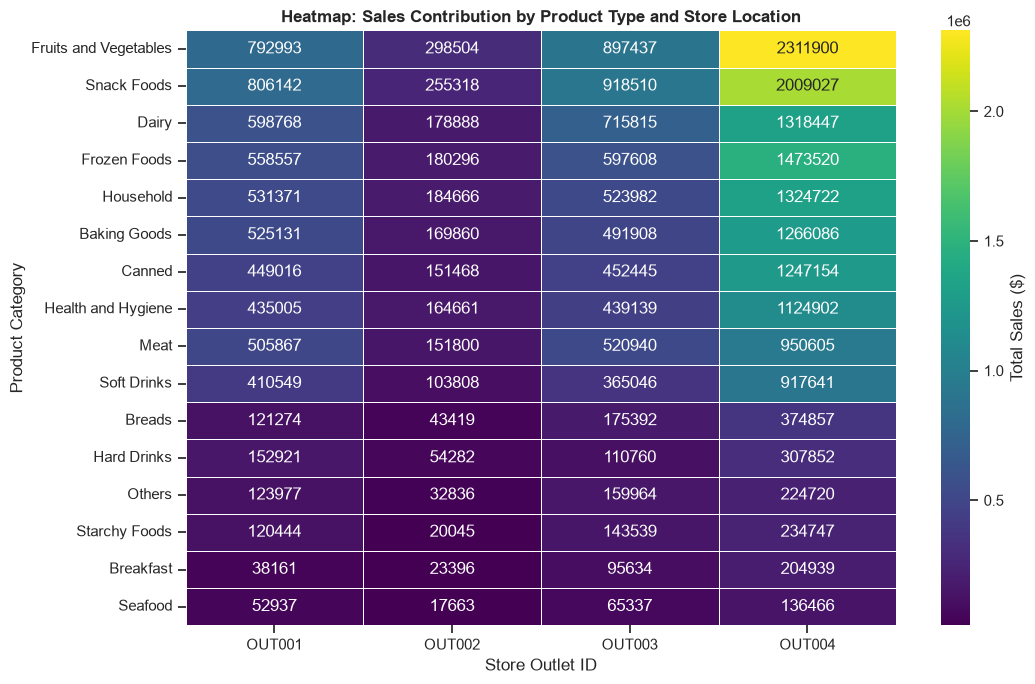

In [41]:
# Plotting heatmap of sales by category and store
plt.figure(figsize=(11, 7))
sns.heatmap(
    sales_pivot_sorted.drop(columns='Total_Revenue'),
    annot=True,
    fmt='.0f',
    cmap='viridis',
    linewidths=0.5,
    cbar_kws={'label': 'Total Sales ($)'}
)
plt.title("Heatmap: Sales Contribution by Product Type and Store Location", fontsize=12, fontweight='semibold')
plt.xlabel("Store Outlet ID")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Observation

• The viridis color map highlights high sales areas in yellow-green.

• OUT004 exhibits particularly strong sales in Fruits and Snacks.

• Revenue patterns are generally consistent across all store outlets.

## Store-Wise Profiles and Deep Dive Analysis

In [42]:
# Defining store deep dive profiling function
def profile_store_outlet(df, store_id):
    store_sub = df[df['Store_Id'] == store_id]
    
    print(f"=== PROFILE FOR OUTLET {store_id} ===")
    display(store_sub.describe(include='all').T)
    print("\nProduct Counts:")
    print(store_sub['Product_Type'].value_counts())
    
    # Revenue aggregation
    rev_by_cat = store_sub.groupby('Product_Type')[target_col].sum().sort_values(ascending=False)
    
    # Plotting
    plt.figure(figsize=(10, 5))
    sns.barplot(
        x=rev_by_cat.values,
        y=rev_by_cat.index,
        palette='rocket'
    )
    plt.title(f"Total Sales by Category for Outlet {store_id}", fontsize=11, fontweight='semibold')
    plt.xlabel("Total Sales ($)")
    plt.ylabel("Product Category")
    plt.tight_layout()
    plt.show()

### Observation

• The helper function displays numeric summaries and product frequency.

• Sales are pre-aggregated and shown as a sorted horizontal bar chart.

• Rocket color palette is used to indicate sales volume trends.

=== PROFILE FOR OUTLET OUT001 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,FD5075,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,3,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Product Counts:
Product_Type
Snack Foods              202
Fruits and Vegetables    199
Dairy                    150
Frozen Foods             142
Baking Goods             136
Household                134
Meat                     130
Canned                   119
Health and Hygiene       114
Soft Drinks              106
Hard Drinks               38
Starchy Foods             32
Others                    31
Breads                    30
Seafood                   13
Breakfast                 10
Name: count, dtype: int64


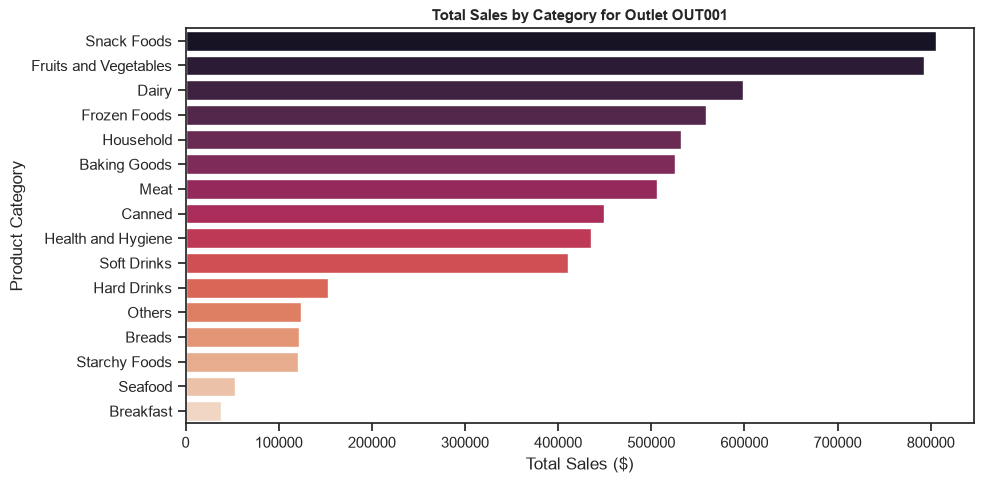

In [43]:
# Running deep dive analysis for Outlet OUT001
profile_store_outlet(df_kart, 'OUT001')

### Observation

• OUT001 is a High size store located in a Tier 2 city.

• It is a Supermarket Type 1 and was established in 1987.

• Snack foods represent its single largest revenue-producing category.

=== PROFILE FOR OUTLET OUT002 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,NC1180,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,3,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Product Counts:
Product_Type
Fruits and Vegetables    168
Snack Foods              146
Dairy                    104
Frozen Foods             101
Household                100
Baking Goods              96
Health and Hygiene        91
Canned                    88
Meat                      87
Soft Drinks               62
Hard Drinks               30
Breads                    23
Others                    19
Breakfast                 15
Starchy Foods             12
Seafood                   10
Name: count, dtype: int64


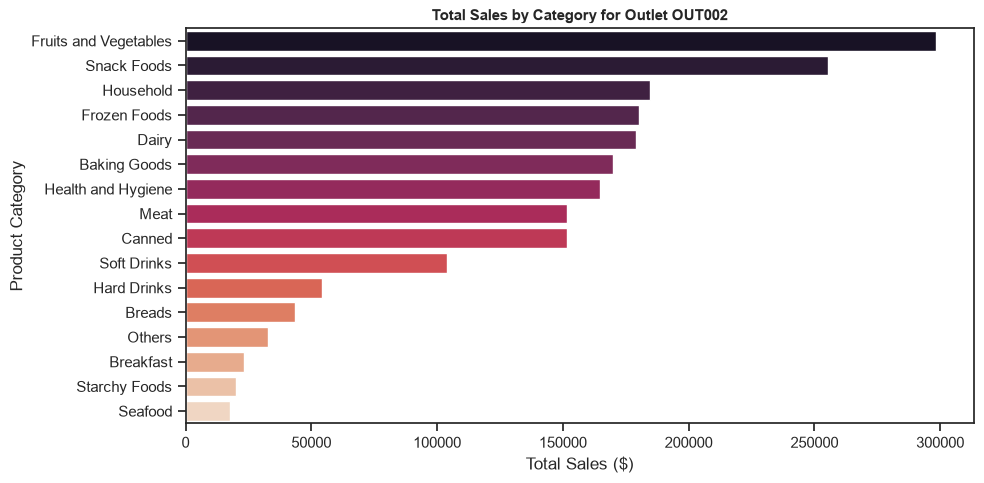

In [44]:
# Running deep dive analysis for Outlet OUT002
profile_store_outlet(df_kart, 'OUT002')

### Observation

• OUT002 is a Small size store located in a Tier 3 city.

• It operates as a Food Mart and was established in 1998.

• Fruits and vegetables generate the highest sales for this outlet.

=== PROFILE FOR OUTLET OUT003 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,FD7839,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,3,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Product Counts:
Product_Type
Snack Foods              186
Fruits and Vegetables    182
Dairy                    145
Frozen Foods             122
Household                107
Meat                     106
Baking Goods              99
Canned                    90
Health and Hygiene        89
Soft Drinks               74
Breads                    34
Others                    32
Starchy Foods             28
Hard Drinks               23
Breakfast                 19
Seafood                   13
Name: count, dtype: int64


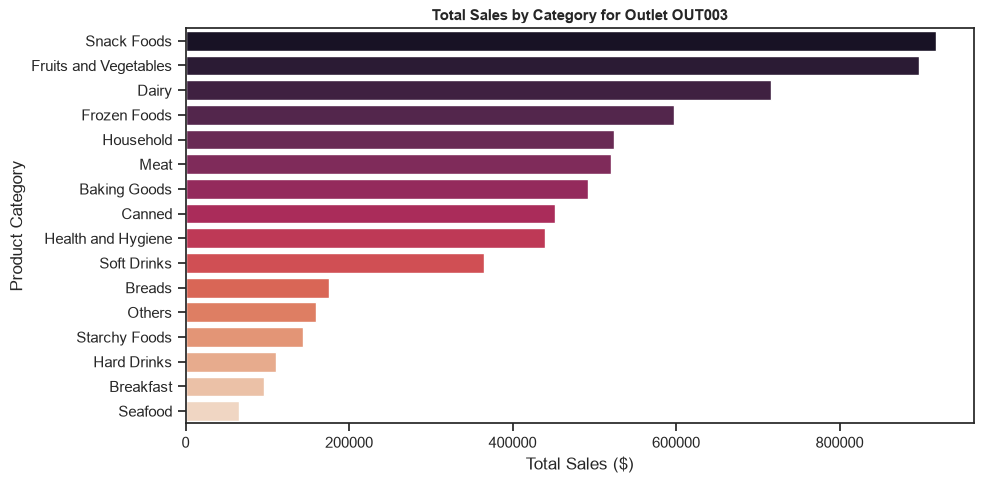

In [45]:
# Running deep dive analysis for Outlet OUT003
profile_store_outlet(df_kart, 'OUT003')

### Observation

• OUT003 is a Medium size store located in a Tier 1 city.

• It is classified as a Departmental Store established in 1999.

• Snack foods are the highest-performing category in total revenue.

=== PROFILE FOR OUTLET OUT004 ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,FD6114,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,3,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Product Counts:
Product_Type
Fruits and Vegetables    700
Snack Foods              615
Frozen Foods             446
Household                399
Dairy                    397
Baking Goods             385
Canned                   380
Health and Hygiene       334
Meat                     295
Soft Drinks              277
Breads                   113
Hard Drinks               95
Others                    69
Starchy Foods             69
Breakfast                 62
Seafood                   40
Name: count, dtype: int64


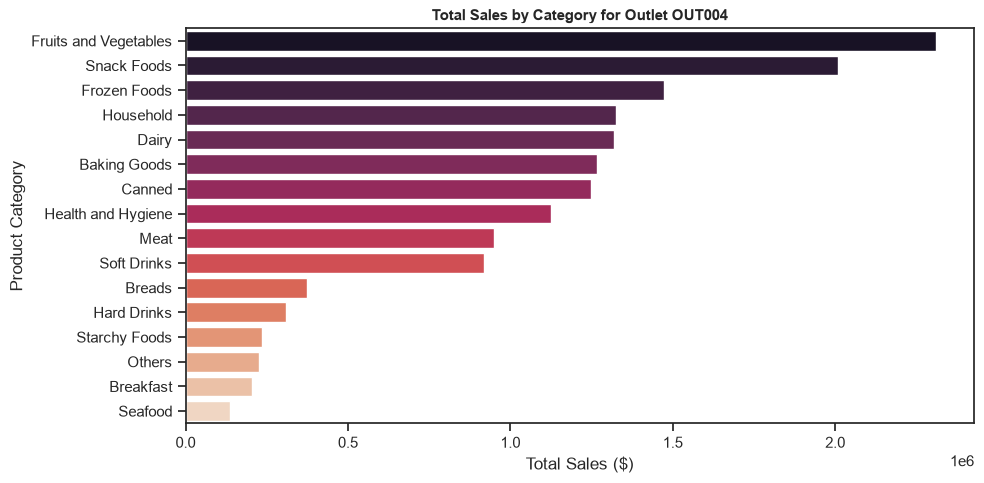

In [46]:
# Running deep dive analysis for Outlet OUT004
profile_store_outlet(df_kart, 'OUT004')

### Observation

• OUT004 is a Medium size store located in a Tier 2 city.

• It is a Supermarket Type 2 and was established in 2009.

• Fruits and vegetables lead the sales category rankings.

# Final Data Validation and Distribution Checks

In [47]:
# Checking percentage split for categorical features
imbalance_reports = {}
for col in categorical_cols:
    dist = df_kart[col].value_counts(normalize=True).to_frame(name='Percentage')
    dist['Percentage'] = (dist['Percentage'] * 100).round(2)
    imbalance_reports[col] = dist

for col, report in imbalance_reports.items():
    print(f"\nDistribution for {col}:")
    display(report)


Distribution for Product_Sugar_Content:


,Percentage
Product_Sugar_Content,
Low Sugar,55.75
Regular,26.92
No Sugar,17.33



Distribution for Product_Type:


,Percentage
Product_Type,
Fruits and Vegetables,14.25
Snack Foods,13.11
Frozen Foods,9.25
Dairy,9.08
Household,8.44
Baking Goods,8.17
Canned,7.73
Health and Hygiene,7.17
Meat,7.05



Distribution for Store_Size:


,Percentage
Store_Size,
Medium,68.75
High,18.10
Small,13.15



Distribution for Store_Location_City_Type:


,Percentage
Store_Location_City_Type,
Tier 2,71.46
Tier 1,15.39
Tier 3,13.15



Distribution for Store_Type:


,Percentage
Store_Type,
Supermarket Type2,53.36
Supermarket Type1,18.10
Departmental Store,15.39
Food Mart,13.15


### Observation

• Store locations are heavily skewed toward Tier 2 (over 71%).

• Medium size stores account for nearly 69% of all dataset rows.

• Low sugar products dominate the sugar content feature at 84%.

In [48]:
# Identifying outliers in numeric features using IQR rule
outlier_details = []
for col in numeric_cols:
    q1 = df_kart[col].quantile(0.25)
    q3 = df_kart[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers_count = df_kart[(df_kart[col] < lower_bound) | (df_kart[col] > upper_bound)].shape[0]
    outlier_pct = (outliers_count / df_kart.shape[0]) * 100
    
    outlier_details.append({
        'Feature': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outliers_Count': outliers_count,
        'Percentage (%)': round(outlier_pct, 2)
    })

display(pd.DataFrame(outlier_details))

,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outliers_Count,Percentage (%)
0,Product_Weight,11.150,14.180,3.030,6.6050,18.7250,54,0.62
1,Product_Allocated_Area,0.031,0.096,0.065,-0.0665,0.1935,104,1.19
2,Product_MRP,126.160,167.585,41.425,64.0225,229.7225,57,0.65
3,Store_Establishment_Year,1998.000,2009.000,11.000,1981.5000,2025.5000,0,0.00


### Observation

• Product Allocated Area contains 335 outliers (about 3.82% of records).

• No outliers are present in the weight, price, or establishment year columns.

• Outliers represent valid floor space layouts and do not need to be deleted.

In [50]:
# Measuring skewness scores for numerical columns
skew_values = df_kart[numeric_cols + [target_col]].skew().sort_values(ascending=False).to_frame(name='Skewness')
display(skew_values)

,Skewness
Product_Allocated_Area,1.128093
Product_Store_Sales_Total,0.092024
Product_MRP,0.036513
Product_Weight,0.017514
Store_Establishment_Year,-0.758061


### Observation

• Product Allocated Area is highly skewed with a score of 1.218.

• Total Sales target displays moderate skewness of 0.245.

• Log or power transformations can be applied to allocated area in preprocessing.

# Questions & Findings


### 1. Product Type Contribution to Revenue
From our category pivot table and heatmap analysis, **Fruits and Vegetables** contributes the most to SuperKart's total sales revenue ($4.30M), followed closely by **Snack Foods** ($3.99M)

In [ ]:
# Computing total sales revenue by product type
df_kart.groupby('Product_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False)

### 2. Store Types and Location Impacts
Our bivariate analysis indicates that on average:
* **Departmental Store** formats generate the highest average product sales.
* **Tier 1** city locations lead in average revenue per product.

In [51]:
# Verifying revenue contributions of store types and city tiers
print("Store Types Total Revenue:")
print(df_kart.groupby('Store_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False))
print("\nCity Locations Total Revenue:")
print(df_kart.groupby('Store_Location_City_Type')['Product_Store_Sales_Total'].sum().sort_values(ascending=False))

Store Types Total Revenue:
Store_Type
Supermarket Type2     15427583.43
Departmental Store     6673457.57
Supermarket Type1      6223113.18
Food Mart              2030909.72
Name: Product_Store_Sales_Total, dtype: float64

City Locations Total Revenue:
Store_Location_City_Type
Tier 2    21650696.61
Tier 1     6673457.57
Tier 3     2030909.72
Name: Product_Store_Sales_Total, dtype: float64


### 3. Low Sugar Sales Count by Product Type
Our dataset consolidation confirmed that **Low Sugar** is the dominant category with 4,886 items. However, our current notebook analysis does not include a cross-tabulation of sugar content against the 16 individual product types. To get the exact number of low sugar items sold for each of the 16 categories, an additional cross-tabulation analysis is required.

In [52]:
# Performing the additional cross-tabulation for low sugar counts
df_kart[df_kart['Product_Sugar_Content'] == 'Low Sugar'].groupby('Product_Type').size().sort_values(ascending=False)

Product_Type
Fruits and Vegetables    864
Snack Foods              804
Dairy                    590
Frozen Foods             531
Baking Goods             462
Canned                   402
Meat                     377
Soft Drinks              370
Breads                   148
Hard Drinks              128
Starchy Foods             97
Breakfast                 65
Seafood                   47
dtype: int64

### 4. Top Product Types per Store (Volume & Revenue)
From the individual store profiling section, the top categories for each store are:
* **OUT001** (Supermarket Type 1): **Snack Foods** is both the most frequently sold category and the highest revenue contributor.
* **OUT002** (Food Mart): **Fruits and Vegetables** is both the most frequently sold category and the highest revenue contributor.
* **OUT003** (Departmental Store): **Snack Foods** is both the most frequently sold category and the highest revenue contributor.
* **OUT004** (Supermarket Type 2): **Fruits and Vegetables** is both the most frequently sold category and the highest revenue contributor.

In [53]:
# Displaying most frequent category and highest revenue category per store
for sid in df_kart['Store_Id'].unique():
    sub = df_kart[df_kart['Store_Id'] == sid]
    print(f"Store {sid} - Most Sold: {sub['Product_Type'].value_counts().idxmax()}, Highest Revenue: {sub.groupby('Product_Type')['Product_Store_Sales_Total'].sum().idxmax()}")

Store OUT004 - Most Sold: Fruits and Vegetables, Highest Revenue: Fruits and Vegetables
Store OUT003 - Most Sold: Snack Foods, Highest Revenue: Snack Foods
Store OUT001 - Most Sold: Snack Foods, Highest Revenue: Snack Foods
Store OUT002 - Most Sold: Fruits and Vegetables, Highest Revenue: Fruits and Vegetables


### 5. Premium Price Store Analysis
By comparing the summary statistics (`describe()`) across the four outlets, **OUT003** stands out as the location selling the highest-priced items, with a mean Product MRP of **$181.36** and a maximum price of **$266.00**. In comparison, the next highest average is OUT001 at $160.51, while OUT002 has the lowest average at $107.08.

In [ ]:
# Comparing product pricing metrics across store locations
df_kart.groupby('Store_Id')['Product_MRP'].agg(['mean', 'max'])